
================ ALPHA COMPARISON (monthly / annualized) =================

FF3  Raw:        0.800%  |  10.04%
FF3  Defensive:  0.888%  |  11.20%
FF5  Raw:        0.725%  |  9.05%
FF5  Defensive:  0.857%  |  10.79%

================ FF3 Raw Strategy ================

                            OLS Regression Results                            
Dep. Variable:                ret_raw   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     9.851
Date:                Sun, 12 Oct 2025   Prob (F-statistic):           2.24e-06
Time:                        22:21:54   Log-Likelihood:                 1256.4
No. Observations:                 746   AIC:                            -2505.
Df Residuals:                     742   BIC:                            -2486.
Df Model:                           3                                         
Covariance Type:    

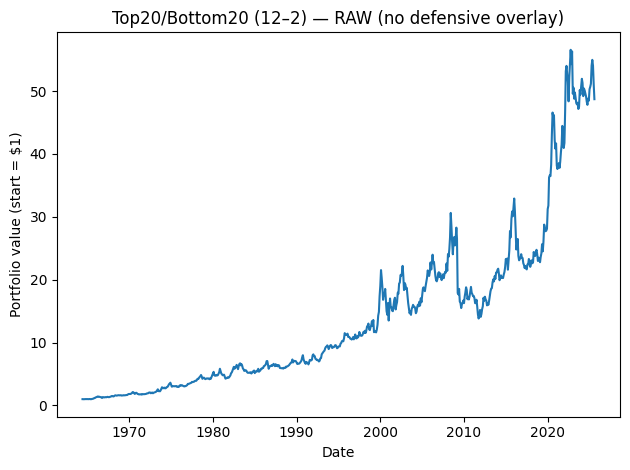

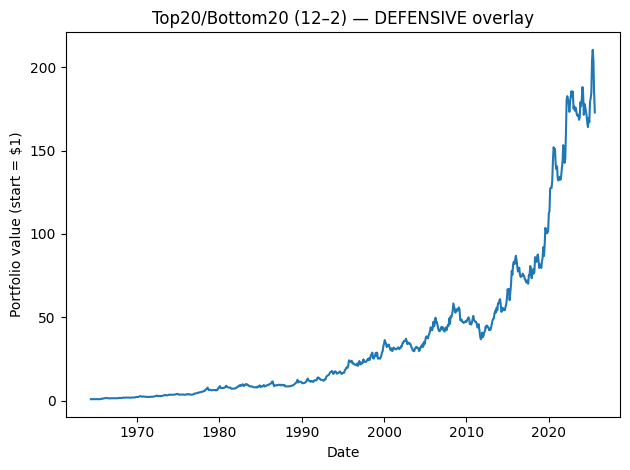

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm


### Inputs
IND_PATH = "30_Industry_Portfolios.csv"
FF3_PATH = "F-F_Research_Data_Factors.csv"
FF5_PATH = "F-F_Research_Data_5_Factors_2x3.csv"

ind = pd.read_csv(IND_PATH, sep=";")
ff3 = pd.read_csv(FF3_PATH, sep=";")
ff5 = pd.read_csv(FF5_PATH, sep=";")

def parse_yyyymm(s):
    s = s.astype(str).str.strip()
    dt = pd.to_datetime(s, format="%Y%m", errors="coerce")
    return dt.fillna(pd.to_datetime(s, format="%Y-%m", errors="coerce"))

# Normalize date columns
ind["DATE"] = parse_yyyymm(ind.pop("Date"))
ff3["DATE"] = parse_yyyymm(ff3.pop("Date"))
ff5["DATE"] = parse_yyyymm(ff5.pop("Date"))

# Convert % to decimals
def to_decimal(df, exclude=("DATE",)):
    cols = [c for c in df.columns if c not in exclude]
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if any(df[c].abs().max(skipna=True) > 1.0 for c in cols):
        for c in cols:
            df[c] = df[c] / 100.0
    return df

ind = to_decimal(ind)
ff3 = to_decimal(ff3)
ff5 = to_decimal(ff5)

# Use FF5 factors
factors = ff5[["DATE","Mkt-RF","SMB","HML","RMW","CMA","RF"]].copy()


### Strategy 1 : 12–2 momentum, Top20/Bottom20
lookback_start, lookback_end = 2, 12
frac = 0.20
industry_cols = [c for c in ind.columns if c != "DATE"]
n = len(ind)

# Compute 12–2 momentum
mom_vals = []
for t in range(n):
    start, end = t - lookback_end, t - lookback_start
    if start < 0:
        mom_vals.append(pd.Series(index=industry_cols, dtype=float))
    else:
        window = ind.iloc[start:end+1][industry_cols]
        mom_vals.append((1.0 + window).prod() - 1.0)
mom = pd.DataFrame(mom_vals)
mom.insert(0, "DATE", ind["DATE"].values)

# Long-short (Top 20% - Bottom 20%) excess return
ls_rows = []
for t in range(n):
    row = mom.iloc[t][industry_cols]
    if row.isna().all():
        continue
    ranks = row.sort_values(ascending=False)
    k = max(1, int(round(frac * len(ranks))))
    long_names, short_names = ranks.index[:k], ranks.index[-k:]
    long_r = ind.iloc[t][long_names].mean()
    short_r = ind.iloc[t][short_names].mean()
    ls_rows.append({"DATE": mom.iloc[t]["DATE"], "ret_raw": long_r - short_r})
ls = pd.DataFrame(ls_rows)



### Strategy 2 : Defensive overlay
target_vol, cap_lev, bad_mkt_mult = 0.04, 2.0, 0.7

# Merge minimal factors for overlay math
ls = ls.merge(factors[["DATE","Mkt-RF","RF"]], on="DATE", how="left")

# 12-month realized vol of raw returns (lag 1 month)
ls["raw_vol_12m"] = ls["ret_raw"].rolling(12).std().shift(1)
ls["lev"] = (target_vol / ls["raw_vol_12m"]).clip(upper=cap_lev)

# Reduce exposure if trailing 12m market total return is negative
tmp = factors.copy()
tmp["MKT_TOTAL"] = tmp["Mkt-RF"] + tmp["RF"]
mkt_total_12m = (1.0 + tmp["MKT_TOTAL"]).rolling(12).apply(np.prod, raw=False) - 1.0
ls = ls.merge(pd.DataFrame({"DATE": tmp["DATE"], "mkt_12m_total": mkt_total_12m.shift(1)}),
              on="DATE", how="left")
ls.loc[ls["mkt_12m_total"] < 0, "lev"] = ls.loc[ls["mkt_12m_total"] < 0, "lev"] * bad_mkt_mult

# Defensive return
ls["ret_def"] = ls["lev"] * ls["ret_raw"]
ls = ls.dropna(subset=["ret_raw"]).reset_index(drop=True)

### Plots
def wealth(x): return (1.0 + x).cumprod()
ls_plot = ls[ls["DATE"] >= "1964-06-01"]
plt.figure()
plt.plot(ls_plot["DATE"], wealth(ls_plot["ret_raw"]))
plt.title("Top20/Bottom20 (12–2) — RAW (no defensive overlay)")
plt.xlabel("Date"); plt.ylabel("Portfolio value (start = $1)")
plt.tight_layout(); plt.savefig("plot_wealth_raw.png", dpi=150)

plt.figure()
plt.plot(ls_plot["DATE"], wealth(ls_plot["ret_def"]))
plt.title("Top20/Bottom20 (12–2) — DEFENSIVE overlay")
plt.xlabel("Date"); plt.ylabel("Portfolio value (start = $1)")
plt.tight_layout(); plt.savefig("plot_wealth_defensive.png", dpi=150)


### Regressions
# Regression frame
reg = ls.drop(columns=[c for c in ["Mkt-RF","RF"] if c in ls.columns]) \
        .merge(factors, on="DATE", how="left")

# FF3
X3 = sm.add_constant(reg[["Mkt-RF","SMB","HML"]])
res3_def = sm.OLS(reg["ret_def"], X3, missing="drop").fit()

# FF5
X5 = sm.add_constant(reg[["Mkt-RF","SMB","HML","RMW","CMA"]])
res5_def = sm.OLS(reg["ret_def"], X5, missing="drop").fit()

# Alpha comparison
def get_alpha(df_with_returns, y_col, factors_df, model="FF5"):
    merged = df_with_returns[["DATE", y_col]].merge(factors_df, on="DATE", how="left")
    if model == "FF3":
        Xcols = ["Mkt-RF", "SMB", "HML"]
    else:
        Xcols = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]
    X = sm.add_constant(merged[Xcols])
    res = sm.OLS(merged[y_col], X, missing="drop").fit()
    a_m = res.params["const"]
    a_y = (1 + a_m)**12 - 1
    return res, a_m, a_y

res3_raw,  a3m_raw,  a3y_raw  = get_alpha(ls, "ret_raw", factors, "FF3")
res3_def2, a3m_def,  a3y_def  = get_alpha(ls, "ret_def", factors, "FF3")
res5_raw,  a5m_raw,  a5y_raw  = get_alpha(ls, "ret_raw", factors, "FF5")
res5_def2, a5m_def,  a5y_def  = get_alpha(ls, "ret_def", factors, "FF5")


### Prints
print("\n================ ALPHA COMPARISON (monthly / annualized) =================\n")
print(f"FF3  Raw:        {a3m_raw*100:.3f}%  |  {a3y_raw*100:.2f}%")
print(f"FF3  Defensive:  {a3m_def*100:.3f}%  |  {a3y_def*100:.2f}%")
print(f"FF5  Raw:        {a5m_raw*100:.3f}%  |  {a5y_raw*100:.2f}%")
print(f"FF5  Defensive:  {a5m_def*100:.3f}%  |  {a5y_def*100:.2f}%")

print("\n================ FF3 Raw Strategy ================\n")
print(res3_raw.summary())
print("\n================ FF3 Defensive Strategy ================\n")
print(res3_def2.summary())
print("\n================ FF5 Raw Strategy ================\n")
print(res5_raw.summary())
print("\n================ FF5 Defensive Strategy ================\n")
print(res5_def2.summary())
